In [1]:
# Εγκατάσταση και εισαγωγή βιβλιοθηκών

# Εγκατάσταση του πακέτου pycaret
# Προκειμένου να αποφευχθεί η ασταθής και χρονοβόρα διαδικασία υποβάθμισης (downgrade) του πυρήνα της Python στο Colab, επιλέχθηκε η απευθείας εγκατάσταση της έκδοσης ανάπτυξης (master branch) από το επίσημο αποθετήριο του PyCaret στο GitHub
!pip install git+https://github.com/pycaret/pycaret.git@master --upgrade

# ΣΗΜΕΙΩΣΗ: Μετά την εγκατάσταση του PyCaret, το Colab ίσως ζητήσει "Restart Session".
# Αν εμφανιστεί σχετικό κουμπί (Restart Runtime/Session), πατήστε το και μετά προχωρήστε στο επόμενο κελί.

# Εισαγωγή της βιβλιοθήκης pandas για τη διαχείριση των δεδομένων
import pandas as pd

# Εισαγωγή της βιβλιοθήκης numpy για να εντοπίσουμε τις «άπειρες» τιμές (infinity) στο dataset
import numpy as np

  Cloning https://github.com/pycaret/pycaret.git (to revision master) to /tmp/pip-req-build-f7wifs5i
  Running command git clone --filter=blob:none --quiet https://github.com/pycaret/pycaret.git /tmp/pip-req-build-f7wifs5i
  Resolved https://github.com/pycaret/pycaret.git to commit 58ec3c282d58e94727f9d5b77b49f241e9103ab3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
# Φόρτωση των δεδομένων

# Το link του CSV αρχείου που περιέχει τα δεδομένα DarkNet
csv_url = "https://raw.githubusercontent.com/jimtak80/AI_EKPA/refs/heads/main/Data/DarkNet.csv"

# Φόρτωση του συνόλου δεδομένων (dataset) σε ένα pandas DataFrame
df = pd.read_csv(csv_url)

# Εμφάνιση των πρώτων 5 γραμμών του dataset για να επιβεβαιώσουμε ότι φορτώθηκε σωστά
display(df.head())

# Εμφάνιση των διαστάσεων του dataset (γραμμές, στήλες)
print(f"\nΤο dataset έχει {df.shape[0]} γραμμές και {df.shape[1]} στήλες.")

/tmp/ipykernel_43401/883140353.py:7: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_url)


,Src_IP,Src_Port,Dst_IP,Dst_Port,Protocol,Flow_Duration,Total_Fwd_Packet,Total_Bwd_packets,Total_Length_of_Fwd_Packet,Total_Length_of_Bwd_Packet,...,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Label-1,Label-2
0,10.152.152.11,57158,216.58.220.99,443,6,229,1,1,0,0,...,0,0,0,0,0,0.000,0,0,Non-Tor,AUDIO-STREAMING
1,10.152.152.11,57159,216.58.220.99,443,6,407,1,1,0,0,...,0,0,0,0,0,0.000,0,0,Non-Tor,AUDIO-STREAMING
2,10.152.152.11,57160,216.58.220.99,443,6,431,1,1,0,0,...,0,0,0,0,0,0.000,0,0,Non-Tor,AUDIO-STREAMING
3,10.152.152.11,49134,74.125.136.120,443,6,359,1,1,0,0,...,0,0,0,0,0,0.000,0,0,Non-Tor,AUDIO-STREAMING
4,10.152.152.11,34697,173.194.65.127,19305,6,10778451,591,400,64530,6659,...,0,0,0,0,1437760000000000,3117718.131,1437760000000000,1437760000000000,Non-Tor,AUDIO-STREAMING



Το dataset έχει 68580 γραμμές και 83 στήλες.


In [3]:
# Διερευνητική Ανάλυση Δεδομένων (EDA)

# 1. Γενικές πληροφορίες για το dataset (τύποι μεταβλητών, πλήθος εγγραφών, memory usage)
print("--- 1. Γενικές Πληροφορίες Dataset ---")
df.info()

# 2. Στατιστική σύνοψη των αριθμητικών μεταβλητών (μέσος όρος, τυπική απόκλιση, min, max)
print("\n--- 2. Στατιστική Σύνοψη ---")
display(df.describe())

# 3. Έλεγχος ελλιπών (κενών) τιμών
total_nans = df.isnull().sum().sum()
print(f"\n--- 3. Έλεγχος Κενών Τιμών ---")
print(f"Συνολικές κενές τιμές στο dataset: {total_nans}")

# 4. Έλεγχος της στήλης Στόχου (Label)
target_col = df.columns[-1] # Αποθηκεύουμε το όνομα της τελευταίας στήλης
print(f"\n--- 4. Ανάλυση Στήλης Στόχου: '{target_col}' ---")

# Εμφανίζουμε πόσες εγγραφές υπάρχουν για κάθε κατηγορία (π.χ. πόσα Tor και πόσα Non-Tor)
# Αυτό μας βοηθάει να δούμε αν το dataset μας είναι ισορροπημένο (balanced)
label_counts = df[target_col].value_counts()
display(label_counts)

--- 1. Γενικές Πληροφορίες Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68580 entries, 0 to 68579
Data columns (total 83 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Src_IP                      68580 non-null  object 
 1   Src_Port                    68580 non-null  int64  
 2   Dst_IP                      68580 non-null  object 
 3   Dst_Port                    68580 non-null  int64  
 4   Protocol                    68580 non-null  int64  
 5   Flow_Duration               68580 non-null  int64  
 6   Total_Fwd_Packet            68580 non-null  int64  
 7   Total_Bwd_packets           68580 non-null  int64  
 8   Total_Length_of_Fwd_Packet  68580 non-null  int64  
 9   Total_Length_of_Bwd_Packet  68580 non-null  int64  
 10  Fwd_Packet_Length_Max       68580 non-null  int64  
 11  Fwd_Packet_Length_Min       68580 non-null  int64  
 12  Fwd_Packet_Length_Mean      68580 non-null  float

,Src_Port,Dst_Port,Protocol,Flow_Duration,Total_Fwd_Packet,Total_Bwd_packets,Total_Length_of_Fwd_Packet,Total_Length_of_Bwd_Packet,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,...,Fwd_Act_Data_Pkts,Fwd_Seg_Size_Min,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min
count,68580.000000,68580.000000,68580.000000,6.858000e+04,68580.000000,68580.000000,6.858000e+04,6.858000e+04,68580.000000,68580.000000,...,68580.000000,68580.000000,68580.0,68580.0,68580.0,68580.0,6.858000e+04,6.858000e+04,6.858000e+04,6.858000e+04
mean,39726.052041,14235.135200,10.978798,2.405470e+07,291.265777,284.729513,2.286576e+05,2.418586e+05,229.046165,18.948936,...,188.358399,15.521260,0.0,0.0,0.0,0.0,6.294694e+14,4.875483e+13,6.540864e+14,5.407995e+14
std,19362.966799,20255.302047,5.577292,4.049607e+07,3399.455076,4873.361494,4.667583e+06,6.522065e+06,846.294647,36.286681,...,2260.533013,8.088541,0.0,0.0,0.0,0.0,6.984537e+14,1.820131e+14,7.179893e+14,6.981754e+14
min,0.000000,0.000000,0.000000,0.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,32898.000000,80.000000,6.000000,1.225882e+05,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,8.000000,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,45126.000000,4644.000000,6.000000,4.201030e+05,2.000000,1.000000,4.400000e+01,0.000000e+00,33.000000,0.000000,...,1.000000,20.000000,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,54712.000000,28326.000000,17.000000,2.716053e+07,5.000000,3.000000,3.360000e+02,2.180000e+02,108.000000,33.000000,...,2.000000,20.000000,0.0,0.0,0.0,0.0,1.433530e+15,1.807551e+07,1.437150e+15,1.433530e+15
max,65534.000000,65533.000000,17.000000,1.200000e+08,238161.000000,470862.000000,7.693074e+08,6.704287e+08,64240.000000,1350.000000,...,113325.000000,44.000000,0.0,0.0,0.0,0.0,1.460000e+15,1.030000e+15,1.460000e+15,1.460000e+15



--- 3. Έλεγχος Κενών Τιμών ---
Συνολικές κενές τιμές στο dataset: 0

--- 4. Ανάλυση Στήλης Στόχου: 'Label-2' ---


,count
Label-2,
P2P,13711
Chat,11478
File-Transfer,11098
Video-Streaming,9486
Email,6145
Audio-Streaming,6055
Browsing,5192
VOIP,3566
AUDIO-STREAMING,1484


In [4]:
# ΓΡΗΓΟΡΗ Αρχικοποίηση PyCaret & Σύγκριση Επιλεγμένων Μοντέλων

from pycaret.classification import setup, compare_models

print("-> 0. Καθαρισμός δεδομένων (αφαίρεση άπειρων τιμών)...")
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

target_col = df.columns[-1]
print(f"-> Η στήλη - στόχος (Label) είναι η: '{target_col}'\n")

# 1. Setup του περιβάλλοντος
print("-> 1. Γίνεται η αρχικοποίηση (Setup) του PyCaret...")
clf_setup = setup(
    data = df,
    target = target_col,
    session_id = 42,
    normalize = True
)

print("\n-> Το Setup ολοκληρώθηκε! Ξεκινάει η ΓΡΗΓΟΡΗ σύγκριση...")

# 2. ΓΡΗΓΟΡΗ ΕΚΠΑΙΔΕΥΣΗ:
# include: Δοκιμάζουμε μόνο 5 επιλεγμένα μοντέλα (dt, rf, lightgbm, lr, nb)
# fold=3: Μειώνουμε τις επαναλήψεις εκπαίδευσης από 10 σε 3
best_model = compare_models(include=['dt', 'rf', 'lightgbm', 'lr', 'nb'], fold=3)

# 3. Εμφάνιση του καλύτερου
print("\n" + "="*50)
print("ΤΟ ΚΑΛΥΤΕΡΟ ΜΟΝΤΕΛΟ ΠΟΥ ΒΡΕΘΗΚΕ ΕΙΝΑΙ:")
print("="*50)
print(best_model)

-> 0. Καθαρισμός δεδομένων (αφαίρεση άπειρων τιμών)...
-> Η στήλη - στόχος (Label) είναι η: 'Label-2'

-> 1. Γίνεται η αρχικοποίηση (Setup) του PyCaret...


,Description,Value
0,Session id,42
1,Target,Label-2
2,Target type,Multiclass
3,Target mapping,"AUDIO-STREAMING: 0, Audio-Streaming: 1, Browsing: 2, Chat: 3, Email: 4, File-Transfer: 5, File-transfer: 6, P2P: 7, VOIP: 8, Video-Streaming: 9, Video-streaming: 10"
4,Original data shape,"(68531, 83)"
5,Transformed data shape,"(68531, 86)"
6,Transformed train set shape,"(47971, 86)"
7,Transformed test set shape,"(20560, 86)"
8,Numeric features,78
9,Categorical features,4



-> Το Setup ολοκληρώθηκε! Ξεκινάει η ΓΡΗΓΟΡΗ σύγκριση...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.7224,0.9785,0.7224,0.7945,0.7120,0.6770,0.6960,11.4233
lr,Logistic Regression,0.6558,0.0000,0.6558,0.6819,0.6447,0.5970,0.6023,7.7567
lightgbm,Light Gradient Boosting Machine,0.4397,0.8731,0.4397,0.7692,0.4549,0.3360,0.4294,63.0300
dt,Decision Tree Classifier,0.4136,0.6519,0.4136,0.7505,0.4269,0.3055,0.3985,4.5800
nb,Naive Bayes,0.2403,0.8277,0.2403,0.5088,0.2183,0.1787,0.2026,1.4100


Processing:   0%|          | 0/25 [00:00<?, ?it/s]


ΤΟ ΚΑΛΥΤΕΡΟ ΜΟΝΤΕΛΟ ΠΟΥ ΒΡΕΘΗΚΕ ΕΙΝΑΙ:
RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=42, verbose=0,
                       warm_start=False)


-> 1. Δημιουργία Γραφημάτων (Αξιολόγηση)...

--- Confusion Matrix (Μήτρα Σύγχυσης) ---


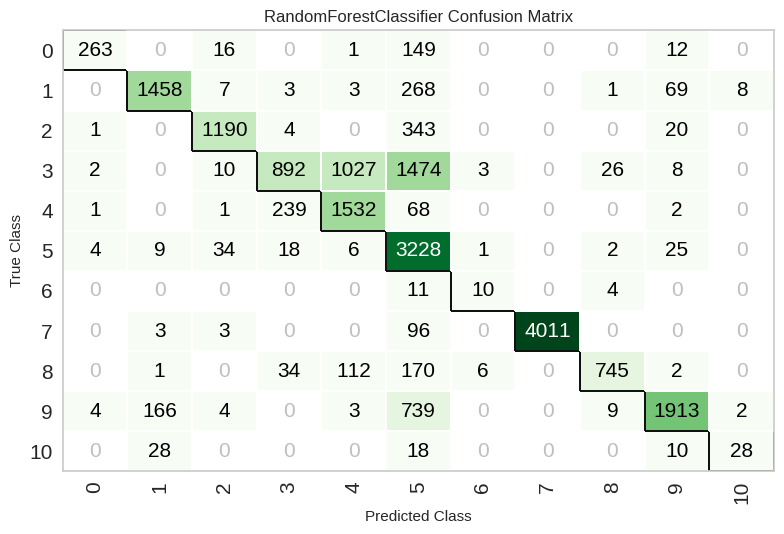

--- Feature Importance (Σημαντικότητα Χαρακτηριστικών) ---


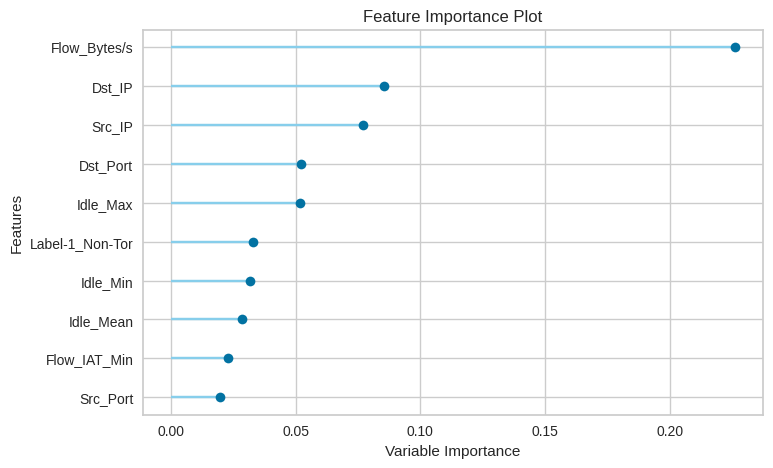

--- ROC Curve ---


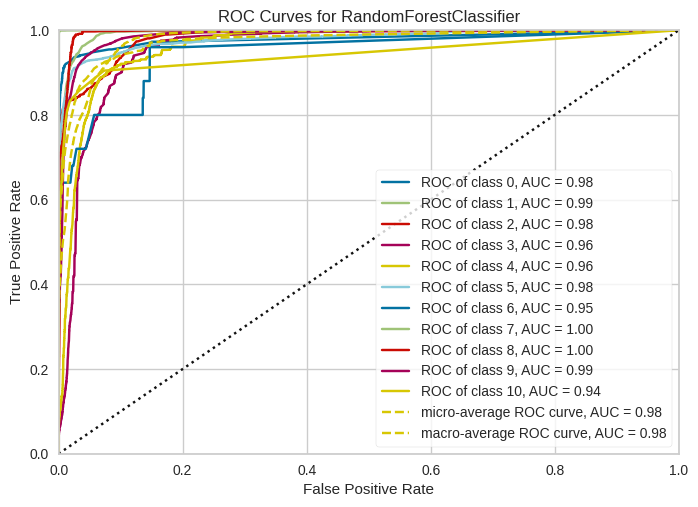


-> 2. Πρόβλεψη σε νέα 'άγνωστα' δεδομένα (Test Set)...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.7427,0.9814,0.7427,0.8066,0.7340,0.7008,0.7179



Τα αποτελέσματα των προβλέψεων (τελευταίες 2 στήλες: 'prediction_label' και 'prediction_score'):


,Src_IP,Src_Port,Dst_IP,Dst_Port,Protocol,Flow_Duration,Total_Fwd_Packet,Total_Bwd_packets,Total_Length_of_Fwd_Packet,Total_Length_of_Bwd_Packet,...,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Label-1,Label-2,prediction_label,prediction_score
32115,131.202.240.87,61009,72.89.67.110,43934,17,63985083,2,0,206,0,...,0,0,63985083,0.000000e+00,63985083,63985083,NonVPN,File-Transfer,File-Transfer,1.0000
66902,131.202.240.242,51782,224.0.0.252,5355,17,409819,2,0,44,0,...,0,0,0,0.000000e+00,0,0,NonVPN,VOIP,File-Transfer,0.3247
51879,10.152.152.11,47472,185.31.19.143,443,6,16178156,2,3,0,53,...,0,0,1437140000000000,1.143022e+07,1437140000000000,1437140000000000,Non-Tor,Video-Streaming,Video-Streaming,0.5800
59963,131.202.240.150,6973,131.202.244.5,53,17,403,1,1,33,185,...,0,0,0,0.000000e+00,0,0,NonVPN,Audio-Streaming,Audio-Streaming,0.9668
26311,10.152.152.11,57916,173.194.116.45,443,6,79196322,61,90,11340,61652,...,0,0,1438020000000000,1.150319e+07,1438020000000000,1438010000000000,Non-Tor,File-Transfer,File-Transfer,0.9300
40607,10.152.152.11,33019,116.116.100.21,18644,6,498554,2,0,0,0,...,0,0,0,0.000000e+00,0,0,Non-Tor,P2P,P2P,1.0000
26071,10.152.152.11,60746,173.194.112.78,80,6,13719410,3,1,0,0,...,0,0,719008000000000,1.016830e+15,1438020000000000,13717714,Non-Tor,File-Transfer,File-Transfer,0.9700
42244,185.21.217.20,52890,10.152.152.11,33155,6,85097814,3,1,1102,0,...,0,0,1456260000000000,6.017268e+07,1456260000000000,1456260000000000,Non-Tor,P2P,P2P,0.5500
54869,131.202.240.150,2255,131.202.244.5,53,17,446,1,1,41,212,...,0,0,0,0.000000e+00,0,0,NonVPN,Video-Streaming,Audio-Streaming,0.3200
29913,10.152.152.11,58029,75.101.155.12,1224,6,426,1,1,0,0,...,0,0,0,0.000000e+00,0,0,Non-Tor,File-Transfer,File-Transfer,0.9971


In [5]:
# Αξιολόγηση και Οπτικοποίηση του Καλύτερου Μοντέλου

from pycaret.classification import plot_model, predict_model

print("-> 1. Δημιουργία Γραφημάτων (Αξιολόγηση)...\n")

# Γράφημα 1: Μήτρα Σύγχυσης (Confusion Matrix)
# Δείχνει πόσες σωστές και πόσες λάθος προβλέψεις έκανε το μοντέλο για κάθε κατηγορία.
print("--- Confusion Matrix (Μήτρα Σύγχυσης) ---")
plot_model(best_model, plot='confusion_matrix')

# Γράφημα 2: Σημαντικότητα Χαρακτηριστικών (Feature Importance)
# Δείχνει ποιες στήλες/χαρακτηριστικά της κίνησης έπαιξαν τον μεγαλύτερο ρόλο στην πρόβλεψη.
print("--- Feature Importance (Σημαντικότητα Χαρακτηριστικών) ---")
plot_model(best_model, plot='feature')

# Γράφημα 3: Καμπύλη ROC (AUC)
# Οπτικοποιεί την ικανότητα του μοντέλου να ξεχωρίζει τις κλάσεις (Tor vs Non-Tor).
print("--- ROC Curve ---")
plot_model(best_model, plot='auc')

print("\n-> 2. Πρόβλεψη σε νέα 'άγνωστα' δεδομένα (Test Set)...")
# Το μοντέλο δοκιμάζεται στα δεδομένα που κράτησε αυτόματα το PyCaret για testing.
predictions = predict_model(best_model)

print("\nΤα αποτελέσματα των προβλέψεων (τελευταίες 2 στήλες: 'prediction_label' και 'prediction_score'):")
display(predictions.head(10))

In [6]:
# Αποθήκευση (Save) του Μοντέλου

from pycaret.classification import save_model, load_model

print("-> Ξεκινάει η αποθήκευση του μοντέλου...")

# Αποθηκεύουμε το μοντέλο με ένα αναγνωρίσιμο όνομα
# Το PyCaret θα δημιουργήσει αυτόματα ένα αρχείο με κατάληξη '.pkl' (Pickle file)
save_model(best_model, 'Final_RF_DarkNet_Model')

print("\n-> Το μοντέλο αποθηκεύτηκε επιτυχώς!")
print("-> (Θα το βρεις στα αριστερά της οθόνης, στο εικονίδιο με τον Φάκελο - Files. Λέγεται 'Final_RF_DarkNet_Model.pkl')")

# --- Προαιρετική Επιβεβαίωση ---
# Ας δοκιμάσουμε να το φορτώσουμε ξανά για να βεβαιωθούμε ότι δουλεύει σωστά
print("\n-> Επιβεβαίωση: Φόρτωση του αποθηκευμένου μοντέλου...")
loaded_model = load_model('Final_RF_DarkNet_Model')
print("-> Το μοντέλο φορτώθηκε με επιτυχία! Το σύστημα είναι έτοιμο για Threat Hunting!")

-> Ξεκινάει η αποθήκευση του μοντέλου...
Transformation Pipeline and Model Successfully Saved

-> Το μοντέλο αποθηκεύτηκε επιτυχώς!
-> (Θα το βρεις στα αριστερά της οθόνης, στο εικονίδιο με τον Φάκελο - Files. Λέγεται 'Final_RF_DarkNet_Model.pkl')

-> Επιβεβαίωση: Φόρτωση του αποθηκευμένου μοντέλου...
Transformation Pipeline and Model Successfully Loaded
-> Το μοντέλο φορτώθηκε με επιτυχία! Το σύστημα είναι έτοιμο για Threat Hunting!
